In [2]:
df = pd.read_csv(
    "../data/raw/household_power_consumption.txt",
    sep=";",
    low_memory=False
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv(
    "../data/raw/household_power_consumption.txt",
    sep=";",
    low_memory=False
)

In [5]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [6]:
df.shape

(2075259, 9)

In [7]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    str    
 3   Global_reactive_power  str    
 4   Voltage                str    
 5   Global_intensity       str    
 6   Sub_metering_1         str    
 7   Sub_metering_2         str    
 8   Sub_metering_3         float64
dtypes: float64(1), str(8)
memory usage: 142.5 MB


In [9]:
df = df.replace("?", np.nan)

In [10]:
numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [11]:
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

In [12]:
df = df.dropna(subset=["Datetime"])
df = df.drop_duplicates()

In [13]:
df["Year"] = df["Datetime"].dt.year
df["Month"] = df["Datetime"].dt.month
df["Month_Name"] = df["Datetime"].dt.month_name()
df["Day"] = df["Datetime"].dt.day
df["Hour"] = df["Datetime"].dt.hour
df["Weekday"] = df["Datetime"].dt.day_name()

df["Is_Weekend"] = df["Weekday"].isin(["Saturday", "Sunday"]).astype(int)
df["Peak_Hour_Flag"] = df["Hour"].isin([17, 18, 19, 20]).astype(int)

In [14]:
df.to_csv("../data/cleaned/energy_cleaned.csv", index=False)

In [15]:
hourly_avg = df.groupby("Hour")["Global_active_power"].mean().reset_index()
hourly_avg

,Hour,Global_active_power
0,0,0.659434
1,1,0.539325
2,2,0.480621
3,3,0.444866
4,4,0.443847
5,5,0.453674
6,6,0.791600
7,7,1.502246
8,8,1.461016
9,9,1.331645


In [16]:
weekday_avg = df.groupby("Weekday")["Global_active_power"].mean().reset_index()
weekday_avg

,Weekday,Global_active_power
0,Friday,1.043394
1,Monday,0.999546
2,Saturday,1.248335
3,Sunday,1.220188
4,Thursday,0.981809
5,Tuesday,1.069796
6,Wednesday,1.082588


In [17]:
weekend_avg = df.groupby("Is_Weekend")["Global_active_power"].mean().reset_index()
weekend_avg

,Is_Weekend,Global_active_power
0,0,1.035472
1,1,1.234232


In [18]:
peak_avg = df.groupby("Peak_Hour_Flag")["Global_active_power"].mean().reset_index()
peak_avg

,Peak_Hour_Flag,Global_active_power
0,0,1.009064
1,1,1.503948


In [19]:
import matplotlib.pyplot as plt

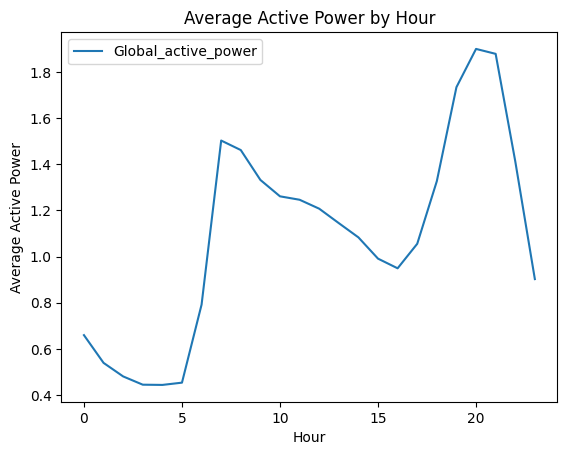

In [20]:
hourly_avg.plot(x="Hour", y="Global_active_power", kind="line")
plt.title("Average Active Power by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Active Power")
plt.show()

In [21]:
weekday_avg = df.groupby("Weekday")["Global_active_power"].mean().reset_index()

weekday_avg

,Weekday,Global_active_power
0,Friday,1.043394
1,Monday,0.999546
2,Saturday,1.248335
3,Sunday,1.220188
4,Thursday,0.981809
5,Tuesday,1.069796
6,Wednesday,1.082588


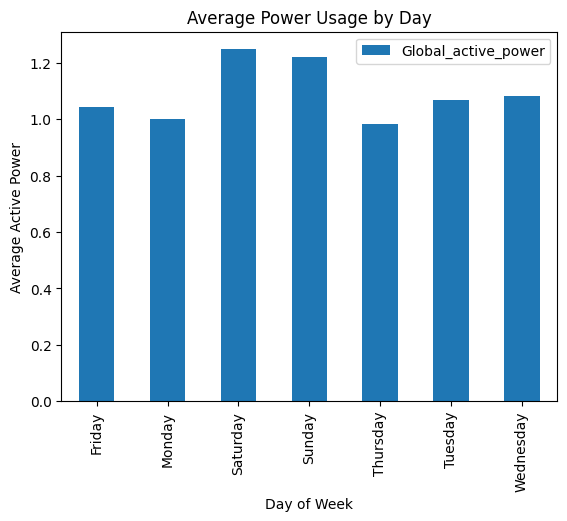

In [22]:
weekday_avg.plot(x="Weekday", y="Global_active_power", kind="bar")

plt.title("Average Power Usage by Day")
plt.xlabel("Day of Week")
plt.ylabel("Average Active Power")
plt.show()

In [23]:
weekday_avg = df.groupby("Weekday")["Global_active_power"].mean().reset_index()
weekday_avg

,Weekday,Global_active_power
0,Friday,1.043394
1,Monday,0.999546
2,Saturday,1.248335
3,Sunday,1.220188
4,Thursday,0.981809
5,Tuesday,1.069796
6,Wednesday,1.082588


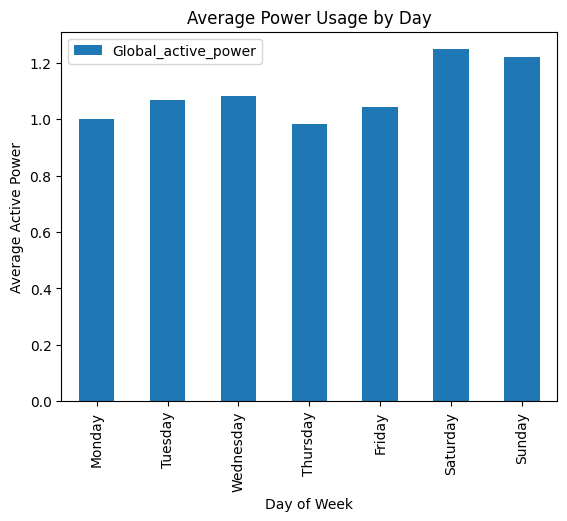

In [27]:
weekday_avg.plot(x="Weekday", y="Global_active_power", kind="bar")

plt.title("Average Power Usage by Day")
plt.xlabel("Day of Week")
plt.ylabel("Average Active Power")
plt.show()

In [26]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_avg["Weekday"] = pd.Categorical(
    weekday_avg["Weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_avg = weekday_avg.sort_values("Weekday")

In [28]:
weekend_avg = df.groupby("Is_Weekend")["Global_active_power"].mean().reset_index()

weekend_avg

,Is_Weekend,Global_active_power
0,0,1.035472
1,1,1.234232


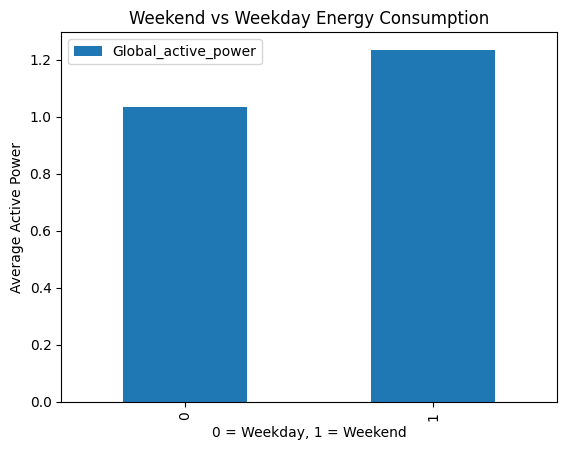

In [29]:
weekend_avg.plot(
    x="Is_Weekend",
    y="Global_active_power",
    kind="bar"
)

plt.title("Weekend vs Weekday Energy Consumption")
plt.xlabel("0 = Weekday, 1 = Weekend")
plt.ylabel("Average Active Power")
plt.show()

In [30]:
weekend_avg = df.groupby("Is_Weekend")["Global_active_power"].mean().reset_index()
weekend_avg

,Is_Weekend,Global_active_power
0,0,1.035472
1,1,1.234232


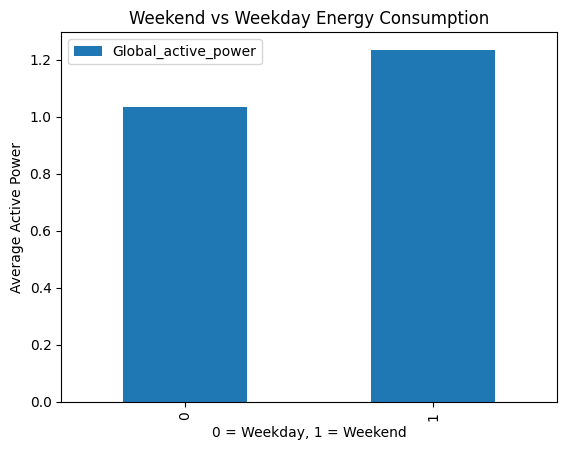

In [31]:
weekend_avg.plot(
    x="Is_Weekend",
    y="Global_active_power",
    kind="bar"
)

plt.title("Weekend vs Weekday Energy Consumption")
plt.xlabel("0 = Weekday, 1 = Weekend")
plt.ylabel("Average Active Power")
plt.show()

In [32]:
monthly_avg = df.groupby("Month_Name")["Global_active_power"].mean().reset_index()

monthly_avg

,Month_Name,Global_active_power
0,April,1.047146
1,August,0.572812
2,December,1.489729
3,February,1.300431
4,January,1.462226
5,July,0.700359
6,June,0.909148
7,March,1.231343
8,May,1.029571
9,November,1.291532


In [33]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_avg["Month_Name"] = pd.Categorical(
    monthly_avg["Month_Name"],
    categories=month_order,
    ordered=True
)

monthly_avg = monthly_avg.sort_values("Month_Name")

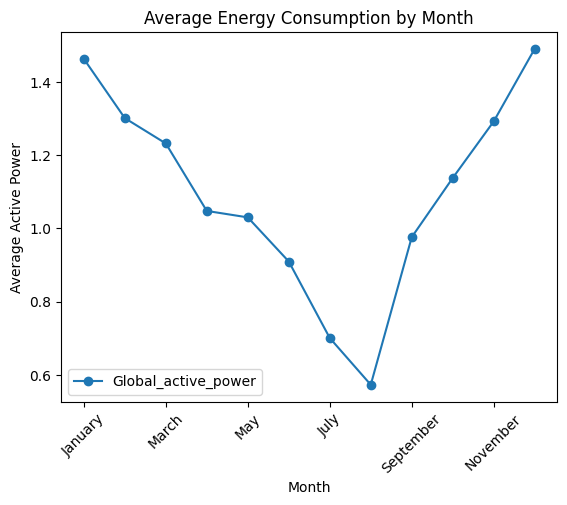

In [34]:
monthly_avg.plot(
    x="Month_Name",
    y="Global_active_power",
    kind="line",
    marker="o"
)

plt.title("Average Energy Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Active Power")
plt.xticks(rotation=45)
plt.show()

In [35]:
monthly_avg = df.groupby("Month_Name")["Global_active_power"].mean().reset_index()
monthly_avg

,Month_Name,Global_active_power
0,April,1.047146
1,August,0.572812
2,December,1.489729
3,February,1.300431
4,January,1.462226
5,July,0.700359
6,June,0.909148
7,March,1.231343
8,May,1.029571
9,November,1.291532


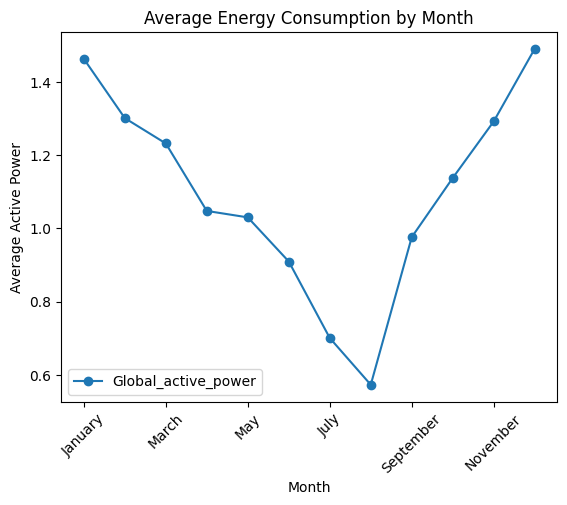

In [36]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_avg["Month_Name"] = pd.Categorical(
    monthly_avg["Month_Name"],
    categories=month_order,
    ordered=True
)

monthly_avg = monthly_avg.sort_values("Month_Name")

monthly_avg.plot(
    x="Month_Name",
    y="Global_active_power",
    kind="line",
    marker="o"
)

plt.title("Average Energy Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Active Power")
plt.xticks(rotation=45)
plt.show()

In [37]:
dashboard_data = df[
    [
        "Datetime",
        "Year",
        "Month",
        "Month_Name",
        "Hour",
        "Weekday",
        "Is_Weekend",
        "Peak_Hour_Flag",
        "Global_active_power",
        "Voltage",
        "Sub_metering_1",
        "Sub_metering_2",
        "Sub_metering_3"
    ]
]

dashboard_data.to_csv("../data/cleaned/energy_dashboard_data.csv", index=False)

dashboard_data.head()

,Datetime,Year,Month,Month_Name,Hour,Weekday,Is_Weekend,Peak_Hour_Flag,Global_active_power,Voltage,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,2006,12,December,17,Saturday,1,1,4.216,234.84,0.0,1.0,17.0
1,2006-12-16 17:25:00,2006,12,December,17,Saturday,1,1,5.360,233.63,0.0,1.0,16.0
2,2006-12-16 17:26:00,2006,12,December,17,Saturday,1,1,5.374,233.29,0.0,2.0,17.0
3,2006-12-16 17:27:00,2006,12,December,17,Saturday,1,1,5.388,233.74,0.0,1.0,17.0
4,2006-12-16 17:28:00,2006,12,December,17,Saturday,1,1,3.666,235.68,0.0,1.0,17.0
